# Endogenous Learning Traps in Transportation Networks

This repository contains the official empirical replication code and data pipelines for the paper:

> **Endogenous Learning Traps in Transportation Networks**

---

## 📊 Empirical Data & Source

The empirical analysis is grounded on the publicly available **Porto taxi trajectory dataset**, originally released for the ECML/PKDD 2015 Taxi Trajectory Prediction Challenge. 

* **Dataset Source:** UCI Machine Learning Repository
* **Direct Access:** [Taxi Service Trajectory Prediction Challenge (ECML/PKDD 2015)](https://archive.ics.uci.edu/dataset/339/taxi+service+trajectory+prediction+challenge+ecml+pkdd+2015)

---

## 🚀 Replication & Inference Execution

The following script processes the raw trajectory data, runs the structural inference pipeline, and exports the full suite of figures and sensitivity checks reported in the paper.

### Prerequisites & Dependencies
Ensure your local environment matches the production requirements:
* Python 3.10+

### Running the Pipeline
To reproduce the core inference results, bootstrap confidence intervals, and decision-level post-opportunity gradients, execute the final pipeline using the command below:

```bash
python porto_learning_traps_v12_final_inference.py \
    --data train.csv.zip \
    --out Results_Porto_V12 \
    --seeds 30

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

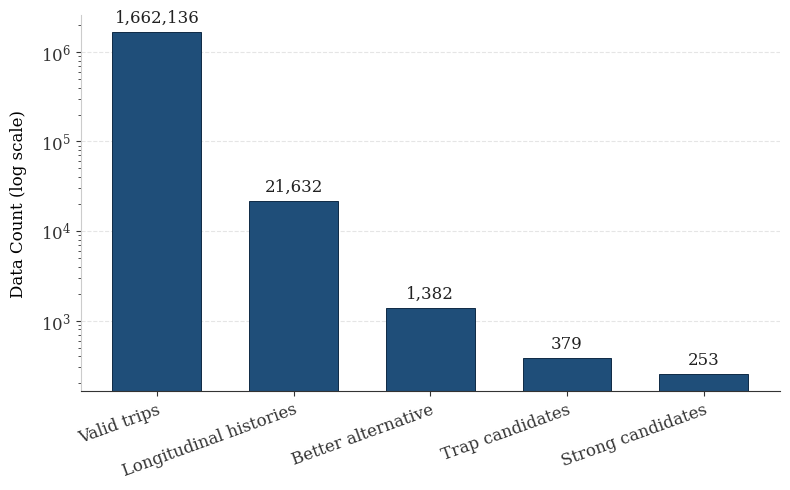

In [2]:
# ============================================================
# 1. Figure
# ============================================================


plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v11_publication/data_for_figures/figure_1_sample_funnel.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {"stage", "count"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}. "
        f"Available columns are: {df.columns.tolist()}"
    )

stages = df["stage"]
counts = df["count"]


fig, ax = plt.subplots(figsize=(8, 5))

ACADEMIC_BLUE = "#1f4e79"

bars = ax.bar(stages, counts, color=ACADEMIC_BLUE, width=0.65, edgecolor="#0f2a45", linewidth=0.7)
ax.set_yscale("log")
ax.set_ylabel("Data Count (log scale)", fontsize=12, fontweight="medium", labelpad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc", zorder=0)
ax.set_axisbelow(True)  # Passe la grille derrière les barres

ax.tick_params(axis="both", which="both", labelsize=12, colors="#333333")
#
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
#
for bar, count in zip(bars, counts):
    ax.annotate(
        f"{int(count):,}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12.,
        fontweight="regular",
        color="#222222",
    )

fig.tight_layout()
plt.show()


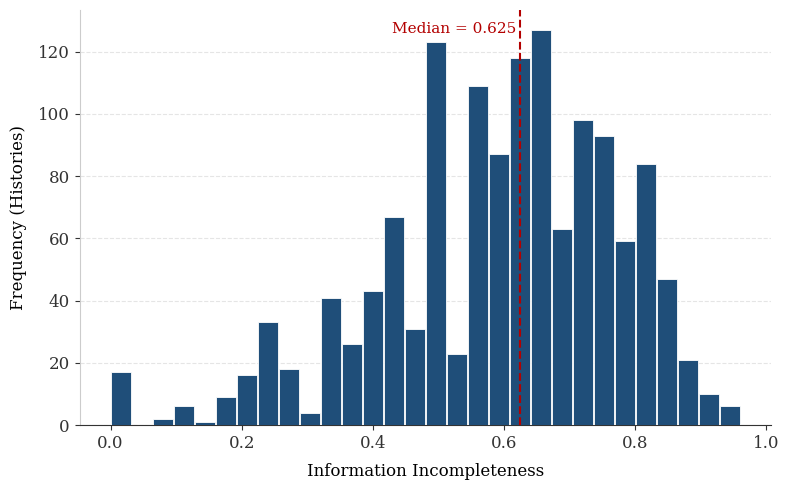

In [3]:
# ============================================================
# 2. Figure
# ============================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v11_publication/data_for_figures/figure_2_incompleteness_distribution.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {"information_incompleteness"}
missing = required_columns.difference(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

x = df["information_incompleteness"].dropna()
median_x = x.median()

# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

BAR_COLOR = "#1f4e79"
MEDIAN_COLOR = "#b30000"

n, bins, patches = ax.hist(
    x,
    bins=30,
    color=BAR_COLOR,
    edgecolor="white",
    linewidth=0.6,
    rwidth=0.95,
    zorder=3,
)

ax.axvline(
    median_x,
    color=MEDIAN_COLOR,
    linestyle="--",
    linewidth=1.5,
    zorder=4,
    label=f"Median = {median_x:.3f}",
)

ax.set_xlabel("Information Incompleteness", fontsize=12, labelpad=8)
ax.set_ylabel("Frequency (Histories)", fontsize=12, labelpad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")

ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc", zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="both", which="major", labelsize=12, colors="#333333")


y_max = ax.get_ylim()[1]
ax.text(
    median_x - 0.196,
    y_max * 0.97,
    f"Median = {median_x:.3f}",
    color=MEDIAN_COLOR,
    ha="left",
    va="top",
    fontsize=11,
    fontweight="medium",
    bbox=dict(
        facecolor="white", edgecolor="none", alpha=0.7, pad=2
    ),
    zorder=5,
)

fig.tight_layout()

plt.show()

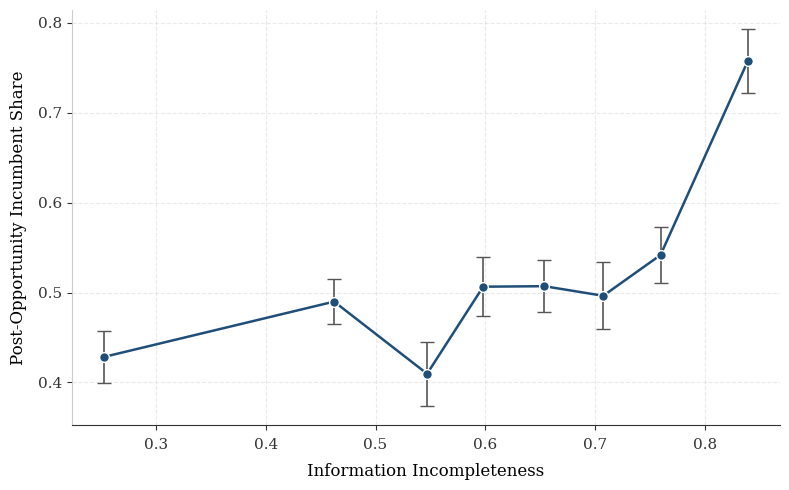

In [4]:
# ============================================================
# 3. Figure
# ============================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v11_publication/data_for_figures/figure_3_persistence_gradient.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {"bin", "x", "mean", "ci95_low", "ci95_high", "n"}
missing = required_columns.difference(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Tri rigoureux selon l'axe X pour éviter les artefacts de tracé
df = df.sort_values("x").copy()

x = df["x"].to_numpy()
y = df["mean"].to_numpy()

yerr_lower = y - df["ci95_low"].to_numpy()
yerr_upper = df["ci95_high"].to_numpy() - y
yerr = [yerr_lower, yerr_upper]

# ============================================================
# 3. Construction Graphique Avancée
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Palette de couleurs académiques
LINE_COLOR = "#1f4e79"
ERROR_COLOR = "#555555"

# Tracé principal avec barres d'erreur stylisées
ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o-",
    color=LINE_COLOR,
    linewidth=1.8,
    markersize=7,
    markerfacecolor=LINE_COLOR,
    markeredgecolor="white",  # Détache élégamment le point de la ligne
    markeredgewidth=1.0,
    ecolor=ERROR_COLOR,
    elinewidth=1.2,
    capsize=5,  # Chapeaux des barres d'erreur légèrement élargis
    capthick=1.2,
    zorder=3,
)

ax.set_xlabel("Information Incompleteness", fontsize=12, labelpad=8)
ax.set_ylabel("Post-Opportunity Incumbent Share", fontsize=12, labelpad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")

ax.grid(True, linestyle="--", alpha=0.4, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)
# Graduations
ax.tick_params(axis="both", which="major", labelsize=11, colors="#333333")

fig.tight_layout()


plt.show()



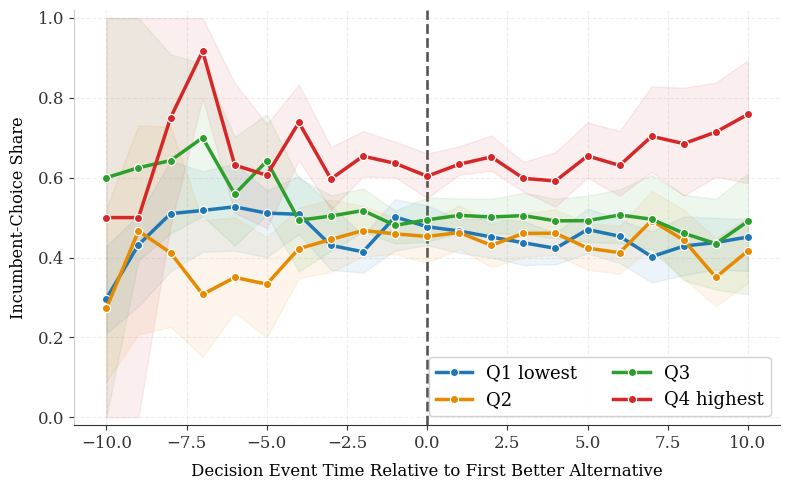

In [5]:
# ============================================================
# 4. Figure
# ============================================================

# ============================================================
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path(
    "C:/Users/fredy/Downloads/Results_Porto_V12/v11_publication/data_for_figures/figure_4_event_response_with_ci.csv"
)
df = pd.read_csv(DATA_FILE)

required_columns = {
    "incompleteness_group",
    "decision_event_time",
    "mean",
    "ci95_low",
    "ci95_high",
}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

group_order = ["Q1 lowest", "Q2", "Q3", "Q4 highest"]

# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#1f77b4", "#e68a00", "#2ca02c", "#d62728"]

for idx, group in enumerate(group_order):
    g = df[df["incompleteness_group"] == group].sort_values("decision_event_time")

    if g.empty:
        continue

    x = g["decision_event_time"].to_numpy()
    y = g["mean"].to_numpy()
    low = g["ci95_low"].to_numpy()
    high = g["ci95_high"].to_numpy()

    color = colors[idx]

    # Courbe principale avec marqueurs détourés
    ax.plot(
        x,
        y,
        marker="o",
        color=color,
        linewidth=2.5,
        markersize=5.9,
        markeredgecolor="white",
        markeredgewidth=0.9,
        label=group,
        zorder=4 + idx,
    )

    ax.fill_between(x, low, high, color=color, alpha=0.08, zorder=2)

ax.axvline(0, color="#555555", linestyle="--", linewidth=1.9, zorder=1, label="_nolegend_")

ax.set_xlabel(
    "Decision Event Time Relative to First Better Alternative",
    fontsize=12.,
    labelpad=8,
)
ax.set_ylabel("Incumbent-Choice Share", fontsize=11.5, labelpad=8)
ax.set_ylim(-0.02, 1.02)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")

ax.grid(True, linestyle="--", alpha=0.3, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.tick_params(axis="both", which="major", labelsize=12., colors="#333333")

ax.legend(
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    fontsize=13,
    loc="lower right",
    facecolor="white",
    ncol=2
)

# Ajustement des marges
fig.tight_layout()


plt.show()


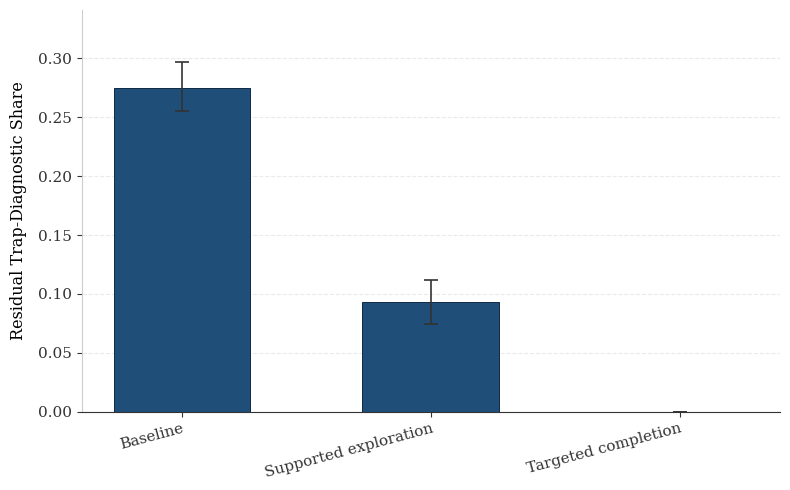

In [6]:
# ============================================================
# 5. Figure
# ============================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v11_publication/data_for_figures/figure_5_intervention_diagnostic_reduction.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {"metric", "mean", "ci95_low", "ci95_high"}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")


order = ["Baseline", "Supported exploration", "Targeted completion"]
df = df.set_index("metric").loc[order].reset_index()

x_labels = df["metric"]
y = df["mean"].to_numpy()

yerr_lower = y - df["ci95_low"].to_numpy()
yerr_upper = df["ci95_high"].to_numpy() - y
yerr = [yerr_lower, yerr_upper]


fig, ax = plt.subplots(figsize=(8, 5))

ACADEMIC_BLUE = "#1f4e79"
ERROR_BAR_COLOR = "#333333"


bars = ax.bar(
    x_labels,
    y,
    yerr=yerr,
    color=ACADEMIC_BLUE,
    edgecolor="#0f2a45",
    linewidth=0.7,
    width=0.55,
    capsize=5,
    error_kw=dict(ecolor=ERROR_BAR_COLOR, elinewidth=1.2, capthick=1.2),
    zorder=3,
)

ax.set_ylabel("Residual Trap-Diagnostic Share", fontsize=11.5, fontweight="medium", labelpad=8)
ax.set_ylim(0, max(df["ci95_high"]) * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")

ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.tick_params(axis="both", which="major", labelsize=11, colors="#333333")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")


fig.tight_layout()

plt.show()


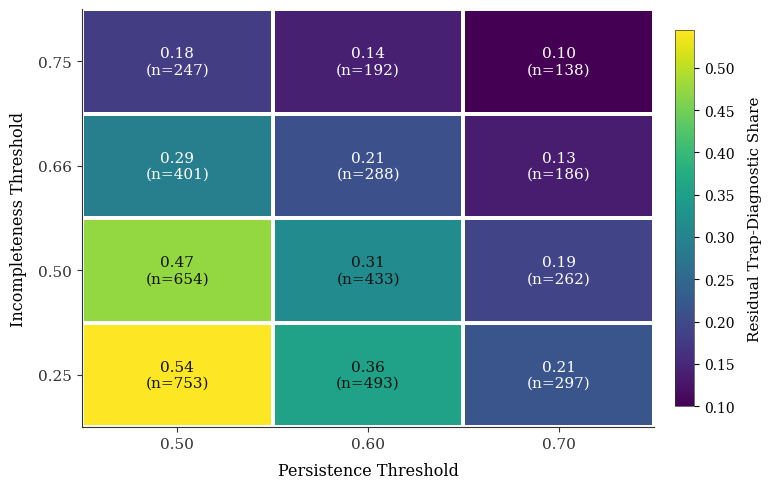

In [7]:
# ============================================================
# 6. Figure
# ============================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v11_publication/data_for_figures/figure_6_threshold_sensitivity.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {
    "persistence_threshold",
    "incompleteness_threshold",
    "better_gap_threshold_min",
    "diagnostic_share_cond_better",
    "n_diagnostic_histories",
}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}.")

BETTER_GAP_THRESHOLD_MIN = 1.0
df_plot = df[df["better_gap_threshold_min"].eq(BETTER_GAP_THRESHOLD_MIN)].copy()

heat = df_plot.pivot(
    index="incompleteness_threshold",
    columns="persistence_threshold",
    values="diagnostic_share_cond_better",
).sort_index(ascending=False)

counts = df_plot.pivot(
    index="incompleteness_threshold",
    columns="persistence_threshold",
    values="n_diagnostic_histories",
).reindex(index=heat.index, columns=heat.columns)

n_rows, n_cols = heat.shape

# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.colormaps["viridis"]

X_grid, Y_grid = np.meshgrid(np.arange(n_cols + 1), np.arange(n_rows + 1))

im = ax.pcolormesh(
    X_grid,
    Y_grid,
    heat.to_numpy(),
    cmap=cmap,
    edgecolors="white",
    linewidths=1.5,
    shading="flat",
)

ax.invert_yaxis()

ax.set_xlabel("Persistence Threshold", fontsize=11.5, labelpad=8)
ax.set_ylabel("Incompleteness Threshold", fontsize=11.5, labelpad=8)

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels([f"{float(x):.2f}" for x in heat.columns])

ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels([f"{float(y):.2f}" for y in heat.index])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="major", labelsize=11, colors="#333333")

# ============================================================
heat_matrix = heat.to_numpy()
counts_matrix = counts.to_numpy()

norm = plt.Normalize(vmin=heat_matrix.min(), vmax=heat_matrix.max())

for i, inc_thr in enumerate(heat.index):
    for j, pers_thr in enumerate(heat.columns):
        value = heat_matrix[i, j]
        n = counts_matrix[i, j]

        rgba = cmap(norm(value))
        luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        text_color = "white" if luminance < 0.45 else "#111111"

        y_pos = i + 0.5

        ax.text(
            j + 0.5,
            y_pos,
            f"{value:.2f}\n(n={int(n)})",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            fontweight="medium" if text_color == "white" else "regular",
        )

cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.9)
cbar.set_label("Residual Trap-Diagnostic Share", fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_linewidth(0.5)

fig.tight_layout()
plt.show()


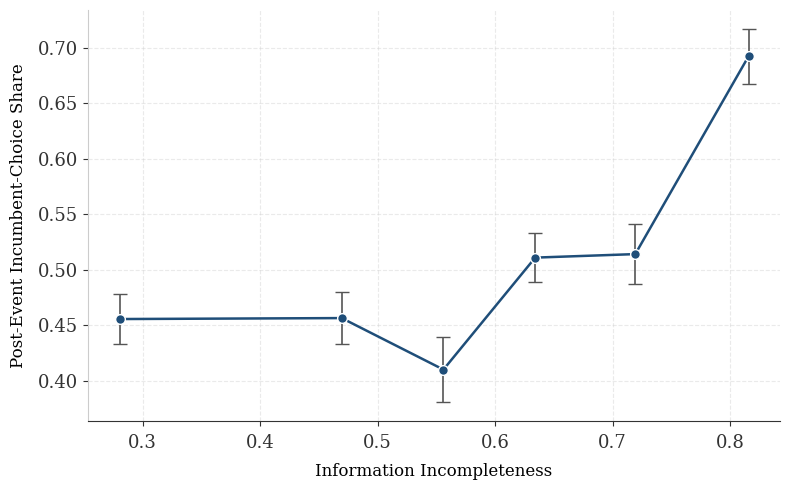

In [8]:
# ============================================================
# 7. Figure
# ============================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v12_inference/data_for_figures/figure_v12_post_gradient_decision_level.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {"bin", "x", "mean", "ci95_low", "ci95_high", "n"}
missing = required_columns.difference(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values("x").copy()

x = df["x"].to_numpy()
y = df["mean"].to_numpy()

yerr_lower = y - df["ci95_low"].to_numpy()
yerr_upper = df["ci95_high"].to_numpy() - y
yerr = [yerr_lower, yerr_upper]

fig, ax = plt.subplots(figsize=(8, 5),)

LINE_COLOR = "#1f4e79"
ERROR_COLOR = "#555555"

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o-",
    color=LINE_COLOR,
    linewidth=1.8,
    markersize=7,
    markerfacecolor=LINE_COLOR,
    markeredgecolor="white",
    markeredgewidth=1.0,
    ecolor=ERROR_COLOR,
    elinewidth=1.2,
    capsize=5,
    capthick=1.2,
    zorder=3,
)

ax.set_xlabel("Information Incompleteness", fontsize=12, labelpad=8)
ax.set_ylabel("Post-Event Incumbent-Choice Share", fontsize=12, labelpad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")

ax.grid(True, linestyle="--", alpha=0.4, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.tick_params(axis="both", which="major", labelsize=12, colors="#333333")

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)

fig.tight_layout()
plt.show()


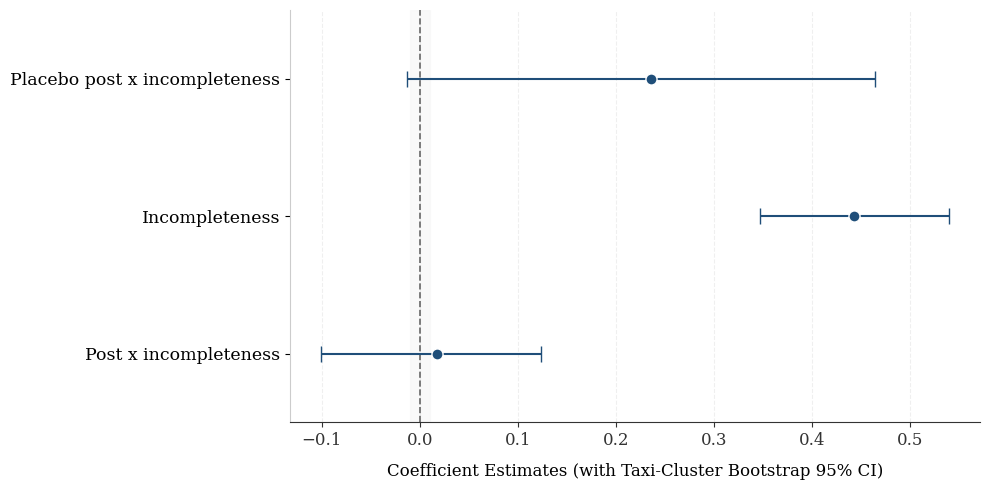

In [9]:
# ============================================================
# 8. Figure
# ============================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

# ============================================================
DATA_FILE = Path("C:/Users/fredy/Downloads/Results_Porto_V12/v12_inference/data_for_figures/figure_v12_reviewer_inference_forest.csv")
df = pd.read_csv(DATA_FILE)

required_columns = {
    "specification",
    "estimand",
    "coefficient",
    "ci95_low_cluster_bootstrap",
    "ci95_high_cluster_bootstrap",
}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

order = [
    "Placebo post x incompleteness",
    "Incompleteness",
    "Post x incompleteness",
]
df = df.set_index("estimand").loc[order].reset_index()

df = df.iloc[::-1].reset_index(drop=True)

y_pos = range(len(df))
x = df["coefficient"].to_numpy()
xerr_lower = x - df["ci95_low_cluster_bootstrap"].to_numpy()
xerr_upper = df["ci95_high_cluster_bootstrap"].to_numpy() - x
xerr = [xerr_lower, xerr_upper]

# ============================================================
fig, ax = plt.subplots(figsize=(10, 5),)

ACADEMIC_BLUE = "#1f4e79"
ERROR_COLOR = "#333333"

ax.errorbar(
    x,
    y_pos,
    xerr=xerr,
    fmt="o",
    color=ACADEMIC_BLUE,
    linewidth=2.0,
    elinewidth=1.5,
    capsize=6,
    capthick=1.5,
    markersize=8,
    markerfacecolor=ACADEMIC_BLUE,
    markeredgecolor="white",
    markeredgewidth=1.0,
    zorder=3,
)

ax.axvline(0, color="#666666", linestyle="--", linewidth=1.2, zorder=1)
ax.axvspan(-0.01, 0.01, color="#f5f5f5", alpha=0.5, zorder=0)

ax.set_xlabel(
    "Coefficient Estimates (with Taxi-Cluster Bootstrap 95% CI)",
    fontsize=12.,
    labelpad=10,
)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df["estimand"], fontsize=12.5)
ax.tick_params(axis="x", which="major", labelsize=12, colors="#333333")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#333333")

ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(-0.5, len(df) - 0.5)

fig.tight_layout()

plt.show()